# Biodiversity at Scale — entregable reproducible

**26 experimentos históricos verificados + 4 ConvNeXt-Tiny nuevos · corpus completo · Khipu · sin ensambles**

**Integrantes:** Jeanpier Garay, Diego Pacheco y Jesus Castillo.

N01–N04 ya terminaron. Este entregable conserva sus resultados originales,
con configuraciones, historiales, predicciones y hashes de inicialización.
El modo predeterminado `review` verifica las 30 evaluaciones sin GPU, red,
descarga del dataset ni entrenamiento. La EDA archivada procede del reporte
ejecutado en Khipu; `prepare` y `report` la recalculan con el corpus completo.

Este notebook contiene de inicio a fin configuración, datos, EDA, Slurm,
entrenamiento, evaluación, curvas, análisis de errores y discusión. Incluye sus
módulos y evidencia histórica; no requiere abrir otros notebooks.

Referencia: [khipu-diego, commit 31c661aaf77e](https://github.com/Jeamipas/iNaturalist2021_U/tree/31c661aaf77e12e9eb389b58ba3cd409b8f7977c/experimento-dp-khipu).
Se recalcularon Top-1/5, Macro/Weighted-F1 de los 26 NPZ: contienen las 100000
imágenes de validación, 10000 especies y 10 imágenes por especie, y todas las
métricas coinciden. El catálogo define 27 experimentos; **L1 no tiene resultados**.
Los históricos se identifican como D-E01…D-T4 para conservar su procedencia.

**Pregunta:** bajo el protocolo de datos y evaluación de Diego, ¿Muon en pesos
internos de ConvNeXt-Tiny cambia convergencia, estabilidad y generalización
respecto a Adam, desde cero y con ImageNet? **Hipótesis:** el efecto del optimizador
podría depender del régimen; la ortogonalización puede aumentar el costo por
paso. No se anticipa un ganador ni una mejora cuantitativa.

Se reutilizan MLP E01/E02, arquitecturas E03/E04/E05, optimización E03/E06–E12,
regularización A1–A6, transfer T1–T4 y long-tail L2–L5. Solo se entrenan N01–N04,
todos ConvNeXt-Tiny. Diego soporta ConvNeXt en su factory, pero no tiene corridas
publicadas con esa arquitectura. No se repiten sus arquitecturas ni ablaciones.
La comparabilidad histórica comparte datos y evaluación; no convierte modelos
y recetas diferentes en una ablación causal de una sola variable.

Ejecutar de arriba abajo: `submit` prepara/envía Slurm; `review` revisa; `status`
consulta; `collect` recupera. Slurm ejecuta `prepare`, `train` y `report` sobre
este mismo notebook. No se inventan métricas pendientes.


In [1]:
import os, sys, json
from pathlib import Path
ROOT=Path(os.environ.get('NATURALIST_ROOT',Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd())).resolve()
MODE=os.environ.get('NATURALIST_MODE','review')
RUN_ID=os.environ.get('NATURALIST_RUN_ID','convnext4_adam_muon_v3')
REMOTE_ROOT='/home/jeanpier.garay/proyectos/naturalist_convnext_v3'
DATA_ROOT=Path(os.environ.get('NATURALIST_DATA_ROOT',ROOT.parent/'recursos'))
OUTPUT_ROOT=ROOT/'outputs'/RUN_ID
SELECTED_EXPERIMENT=os.environ.get('NATURALIST_EXPERIMENT')
SETTINGS={'run_id':RUN_ID,'remote_root':REMOTE_ROOT,
          'reuse_project_root':None,
          'data_ready_job':None,'prepare_cpus':32,'prepare_memory':'96G',
          'gpu_smoke':True,'job_name':'nat_convnext4',
          'gpu_gres':'shard:rtxa6000:8','gpu_node':'ds001'}
# Independent replay: data_ready_job=None and reuse_project_root=None.
os.environ['INAT_ROOT']=str(DATA_ROOT)
os.environ['INAT_CACHE']=str(DATA_ROOT/'cache_diego_144_v2')
os.environ['INAT_RESULTADOS']=str(OUTPUT_ROOT)
os.environ.setdefault('TORCH_DETERMINISTA','0') # Diego's benchmark policy; see limits
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG',':4096:8')
PLAN=[{'id': 'N01', 'descripcion': 'ConvNeXt-Tiny desde cero con Adam', 'modelo': 'convnext_tiny', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'stochastic_depth_prob': 0.1}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.001, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42, 'muon_lr': 0.02}, {'id': 'N02', 'descripcion': 'ConvNeXt-Tiny desde cero con Muon + Adam auxiliar', 'modelo': 'convnext_tiny', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'stochastic_depth_prob': 0.1}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'muon', 'lr': 0.001, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42, 'muon_lr': 0.02}, {'id': 'N03', 'descripcion': 'ConvNeXt-Tiny ImageNet: fine-tuning completo con Adam', 'modelo': 'convnext_tiny', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'stochastic_depth_prob': 0.1}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.001, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42, 'muon_lr': 0.02}, {'id': 'N04', 'descripcion': 'ConvNeXt-Tiny ImageNet: fine-tuning completo con Muon + Adam auxiliar', 'modelo': 'convnext_tiny', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'stochastic_depth_prob': 0.1}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'muon', 'lr': 0.001, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42, 'muon_lr': 0.02}]
assert len(PLAN)==4 and {c['modelo'] for c in PLAN}=={'convnext_tiny'}
assert [c['preentrenado'] for c in PLAN]==[False,False,True,True]
for left,right in ((PLAN[0],PLAN[1]),(PLAN[2],PLAN[3])):
    assert {k:v for k,v in left.items() if k not in ('id','descripcion','optimizador')} == {k:v for k,v in right.items() if k not in ('id','descripcion','optimizador')}
OUTPUT_ROOT.mkdir(parents=True,exist_ok=True)
print('Modo:',MODE,'| Run:',RUN_ID,'| Nuevos:',[c['id'] for c in PLAN])


Modo: review | Run: convnext4_adam_muon_v3 | Nuevos: ['N01', 'N02', 'N03', 'N04']


In [2]:
import json, sys, base64, zlib, hashlib
from pathlib import Path
BUNDLE_PAYLOAD='...'
BUNDLE_SHA256='50b0f14fbf4d7b4701d501d7ca83c6a4b743a8d85c1ac347e5ba9ed94b223f24'
_bundle=json.loads(zlib.decompress(base64.b64decode(BUNDLE_PAYLOAD)))
assert hashlib.sha256(json.dumps(_bundle,sort_keys=True).encode()).hexdigest()==BUNDLE_SHA256
for _relative,_source in _bundle.items():
    _path=(ROOT/_relative).resolve()
    if not _path.is_relative_to(ROOT): raise ValueError('Ruta fuera del proyecto')
    if _relative=='src/__init__.py' and _path.exists(): continue
    if _path.exists() and _path.read_text(encoding='utf-8').replace('\r\n','\n')!=_source:
        raise RuntimeError(f'Fuente modificada: {_relative}. Regenerar el notebook; no se sobrescribe silenciosamente.')
    _path.parent.mkdir(parents=True,exist_ok=True)
    if not _path.exists(): _path.write_text(_source,encoding='utf-8',newline='\n')
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
print('Fuentes y evidencia verificadas:',len(_bundle),'| SHA256:',BUNDLE_SHA256)


Fuentes y evidencia verificadas: 23 | SHA256: 50b0f14fbf4d7b4701d501d7ca83c6a4b743a8d85c1ac347e5ba9ed94b223f24


## 1. Resumen antes del entrenamiento y controles

| Nuevo | Inicio y modelo | Optimizador | Propósito |
|---|---|---|---|
| N01 | ConvNeXt-Tiny desde cero | Adam: cabeza/backbone 0.001 | Control scratch |
| N02 | Mismos pesos aleatorios que N01 | Muon 0.02 + Adam auxiliar 0.001 | Tratamiento frente a N01 |
| N03 | ConvNeXt-Tiny ImageNet V1, ajuste completo | Adam: cabeza 0.001 / backbone 0.0001 | Control transfer |
| N04 | Mismos pesos ImageNet y cabeza que N03, ajuste completo | Muon backbone 0.002 + Adam cabeza 0.001 / vectores backbone 0.0001 | Tratamiento frente a N03 |

Los cuatro tienen 35510128 parámetros y todos son entrenables. Transfer
learning se implementa como **fine-tuning completo**, no backbone congelado.
La cabeza aleatoria tiene 10000 salidas. ImageNet es `IMAGENET1K_V1` de torchvision,
con archivo `convnext_tiny-983f1562.pth` verificado y hash completo registrado.
Cada pareja comparte el estado inicial completo; la cabeza recibe la misma
inicialización también entre scratch y transfer.

500000 train / 100000 val, 10000 especies. Almacenamiento 144 px: lado corto,
bicúbica y centro cuadrado. Entrada 128 px: crop aleatorio con roi_align y flip
horizontal, normalización ImageNet. Batch 256, val 1024; máximo 16 épocas;
warmup 1 época y coseno **por paso**; clipping 5; LayerNorm; dropout 0;
stochastic depth 0.1 explícito; CE sin smoothing.
Seed 42, orden resiembrado por época. Selección Top-1, paciencia 4, min_delta
0.001. AMP BF16 y channels-last, igual que Diego.

L2 acoplado 5e-5 en matrices; sesgos, normalización y layer_scale sin penalizar.
Muon recibe la misma penalización antes de actualizar; momentum 0.95, Nesterov,
5 pasos Newton–Schulz. La cabeza y vectores usan Adam. Esto compara recetas
fijas; no equivale a buscar el mejor LR de cada optimizador. Muon usa únicamente
pesos internos de convolución/linear; layer_scale es un vector por canal aunque
tenga forma [C,1,1], y usa Adam. El factor 0.1 del backbone transfer afecta tanto
a matrices Muon como a vectores Adam y a todas las capas backbone del control Adam.

**Diferencia deliberada:** Diego descarta el último lote (1953 lotes, 499968
imágenes). Los cuatro incluyen las 500000 (1954 lotes, último de 32).
**Pares controlados: N01↔N02 y N03↔N04.** Entre regímenes cambia también el
LR backbone para proteger ImageNet: no se atribuye todo su efecto a los pesos.
Los planes anteriores de 11 y de dos ResNet quedan sustituidos y preservados.


In [3]:
from IPython.display import display
from src.diego_workflow import evidence, plan_from_evidence
EVIDENCE=evidence(ROOT)
assert PLAN==plan_from_evidence(ROOT)
display(PLAN)
print('26 referencias verificadas; L1 sin resultado. Solo N01–N04 ConvNeXt se entrenan.')


[{'id': 'N01',
  'descripcion': 'ConvNeXt-Tiny desde cero con Adam',
  'modelo': 'convnext_tiny',
  'preentrenado': False,
  'ajuste': 'completo',
  'bn': True,
  'dropout': 0.0,
  'modelo_kw': {'stochastic_depth_prob': 0.1},
  'datos': 'completo',
  'aumento': 'basico',
  'muestreo': 'uniforme',
  'optimizador': 'adam',
  'lr': 0.001,
  'factor_lr_backbone': 1.0,
  'weight_decay': 5e-05,
  'batch': 256,
  'epocas': 16,
  'warmup': 1.0,
  'clip': 5.0,
  'perdida': 'ce',
  'label_smoothing': 0.0,
  'paciencia': 4,
  'min_delta': 0.001,
  'semilla': 42,
  'muon_lr': 0.02},
 {'id': 'N02',
  'descripcion': 'ConvNeXt-Tiny desde cero con Muon + Adam auxiliar',
  'modelo': 'convnext_tiny',
  'preentrenado': False,
  'ajuste': 'completo',
  'bn': True,
  'dropout': 0.0,
  'modelo_kw': {'stochastic_depth_prob': 0.1},
  'datos': 'completo',
  'aumento': 'basico',
  'muestreo': 'uniforme',
  'optimizador': 'muon',
  'lr': 0.001,
  'factor_lr_backbone': 1.0,
  'weight_decay': 5e-05,
  'batch': 256

26 referencias verificadas; L1 sin resultado. Solo N01–N04 ConvNeXt se entrenan.


## 2. Preparación reproducible y Khipu

Se reutilizan las descargas y entorno propio del proyecto. La ejecución nueva
vive en `naturalist_convnext_v3`; no sobrescribe la preparación anterior. Un job
CPU espera al corpus, verifica todas las anotaciones/paths, reproduce el
preprocesamiento de Diego con 32 procesos y verifica los 26 NPZ por SHA256.
Para reproducción independiente, configurar `data_ready_job=None` y
`reuse_project_root=None`: el notebook prepara entorno y corpus oficiales.

Índices ordenados por etiqueta/filename, igual que Diego; se verifica el orden
de labels de validación contra los NPZ. No se excluyen imágenes silenciosamente.
Python 3.11.11, PyTorch 2.6.0, torchvision 0.21.0, Pillow 11.0.0 y versiones
fijadas en requirements-full; el freeze efectivo queda guardado.

Smoke CUDA/BF16 con entradas sintéticas comprueba inicialización idéntica y
actualizaciones finitas; NO genera métricas del proyecto. Después se envían
cuatro tareas y reporte por afterok. El smoke prueba batch train 256 y val 1024
en los cuatro modelos para detectar falta de VRAM antes del corpus completo.
RTX A6000 compartida en ds001: `shard:rtxa6000:8`, 32 CPU y 96 GiB por tarea.
El job 54608 pasó los cuatro smoke CUDA/BF16 con los lotes del protocolo;
pico de memoria PyTorch 5.54 GiB. La MIG de 5 GB falló por falta de VRAM.
Los shards no garantizan una porción fija de VRAM ni de cómputo. Los cuatro
experimentos usan la misma reserva y se ejecutan secuencialmente. El uso de
otros usuarios puede variar: los tiempos son descriptivos y no permiten
atribuir diferencias de velocidad únicamente al optimizador.
Para reservar el dispositivo completo en una nueva ejecución, configurar
`gpu_gres='gpu:rtxa6000:1'` y `gpu_node=None` antes de enviar los jobs.

Checkpoints atómicos: modelo, optimizador compuesto, scheduler por paso,
historial y RNG Python/NumPy/Torch/CUDA. Se reencola únicamente la tarea propia
si otra época no cabe en siete horas; watchdog a 7h45 repite una época incompleta.
Cerrar SSH o la laptop no detiene los jobs.


In [4]:
from src.khipu_pipeline import submit, status, collect
JOBS_PATH=OUTPUT_ROOT/'khipu_jobs.json'
JOBS=json.loads(JOBS_PATH.read_text()) if JOBS_PATH.exists() else None
if MODE=='submit': JOBS=submit(ROOT,SETTINGS,PLAN)
elif MODE=='status': print(status(JOBS) if JOBS else 'Sin jobs registrados')
elif MODE=='collect': print(collect(ROOT,JOBS) if JOBS else 'Sin jobs registrados')
elif MODE=='prepare':
    from src.full_data import prepare_full_data
    from src.diego_workflow import prepare_compatible_cache
    CORPUS=prepare_full_data(DATA_ROOT)
    CACHE_AUDIT=prepare_compatible_cache(ROOT,DATA_ROOT,workers=32)
    display(CACHE_AUDIT)
elif MODE not in ('review','train','report'): raise ValueError('Modo desconocido')


## 3. EDA y bases de las comparaciones

Mini es balanceada: 50 train / 10 val por especie. ResNet emplea bloques
residuales y BN; EfficientNet-B0 usa MBConv. D-E03/E04/E05 ya las comparan.
MLP aplana píxeles y su número de parámetros crece con el área de entrada;
las capas 2048→1024 de Diego difieren del MLP anterior: se usa su baseline.
128 px limita detalle y transfer de ImageNet. Crop puede eliminar rasgos;
flip es plausible; jitter intenso puede alterar señales que distinguen especies.
La EDA mide cantidades, dimensiones y taxonomía del corpus completo, además
de mostrar variación dentro de especies y especies del mismo género.


EDA archivada del reporte Khipu: Mini completo 500000 train, 100000 val; se recalcula desde el corpus en prepare/report
{'train_images': 500000,
 'val_images': 100000,
 'species': 10000,
 'train_per_species': 50,
 'val_per_species': 10,
 'missing_files': 0,
 'overlapping_filenames': 0,
 'train_json_sha256': '481b14dcabe945181e79c2cb8a65cf257e767468db8d94a9559b0ce639086060',
 'val_json_sha256': 'a2eaf1f38e7a275432c3d6d119ed41332412484bea26d71139837c13dbf027a9',
 'species_by_kingdom': {'Animalia': 5388, 'Fungi': 341, 'Plantae': 4271},
 'species_by_supercategory': {'Animalia': 142,
  'Arachnids': 153,
  'Insects': 2526,
  'Ray-finned Fishes': 183,
  'Amphibians': 170,
  'Birds': 1486,
  'Mammals': 246,
  'Reptiles': 313,
  'Mollusks': 169,
  'Fungi': 341,
  'Plants': 4271},
 'dimension_summary': {'train': {'images_with_dimensions': 500000,
   'min_width': 61,
   'max_width': 500,
   'min_height': 63,
   'max_height': 500},
  'val': {'images_with_dimensions': 100000,
   'min_width': 91,
  

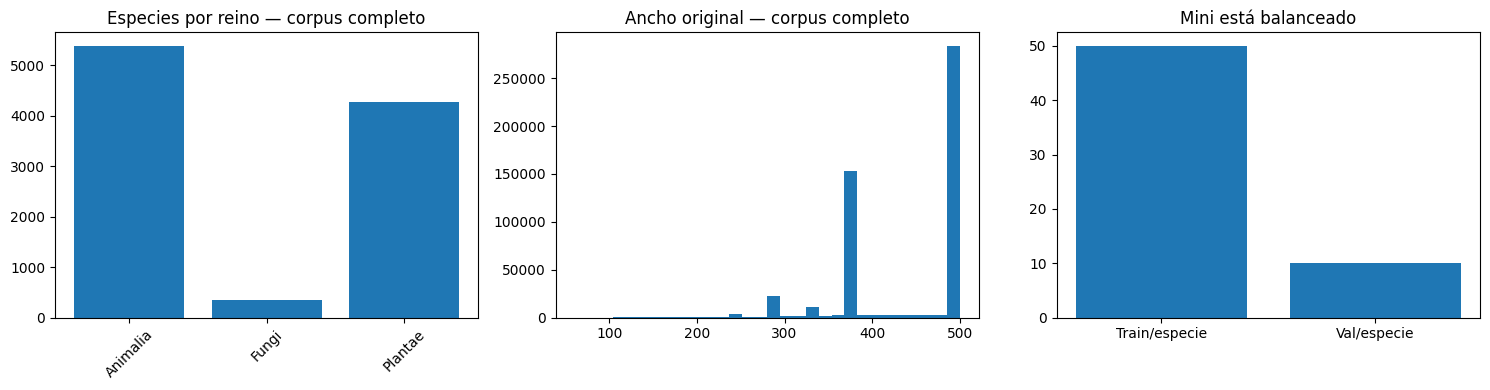

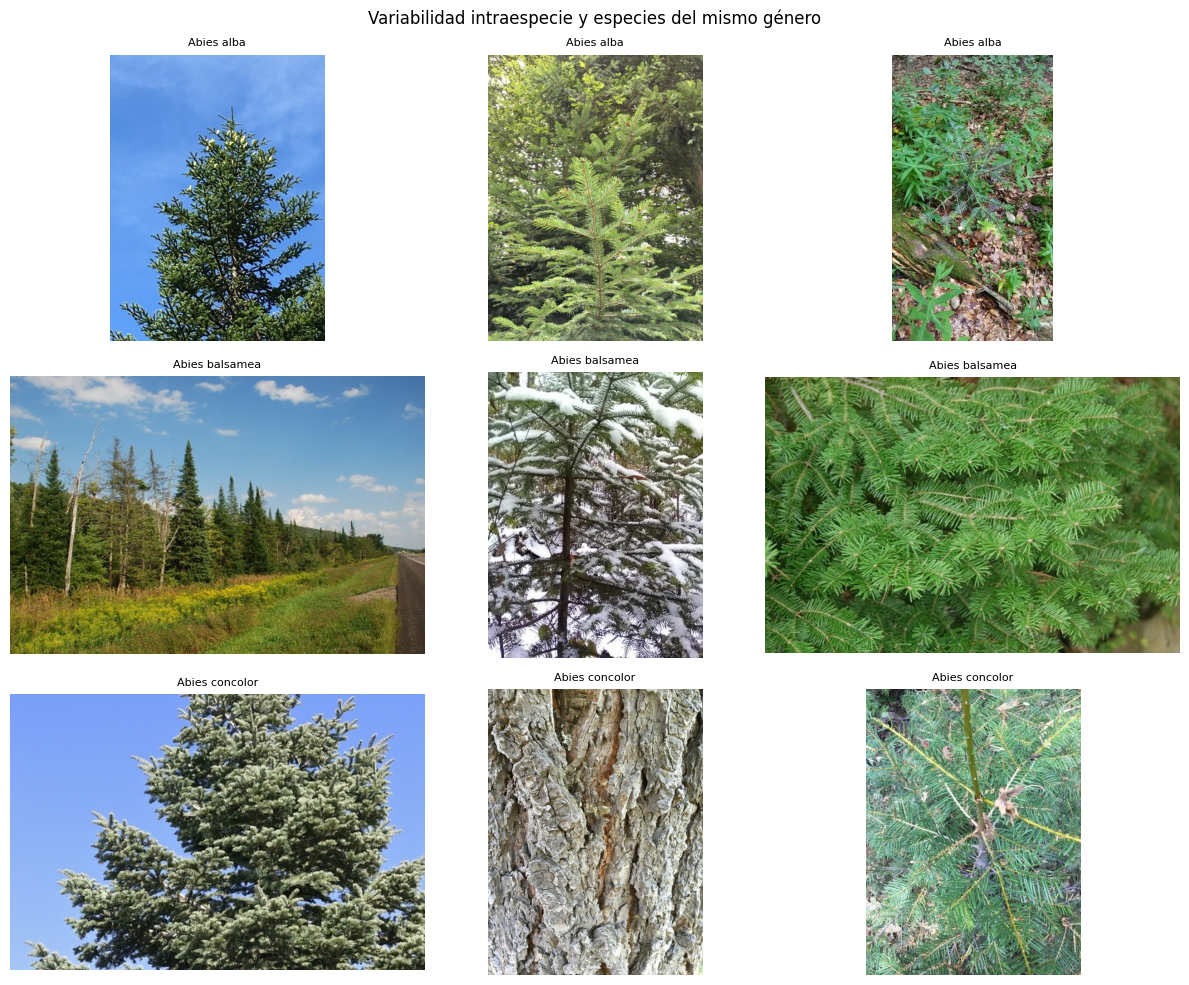

In [5]:
if MODE in ('prepare','report'):
    from src.full_data import audit_corpus
    from src.full_experiment import show_eda
    CORPUS=audit_corpus(DATA_ROOT,OUTPUT_ROOT/'corpus_manifest.json')
    display({k:v for k,v in CORPUS.items() if k!='category_to_label'})
    show_eda(DATA_ROOT,CORPUS)
elif MODE=='review':
    from src.delivery_evidence import show_eda_snapshot
    show_eda_snapshot(ROOT)
else: print('EDA completa en preparación/reporte CPU.')


## 4. Entrenamiento nuevo y evaluación

Torchvision inicializa backbone aleatorio o ImageNet y cabeza de 10000 clases.
El SHA256 inicial debe coincidir en N01/N02 y en N03/N04. Se valida con las 100000 imágenes
después de cada época; CE de validación sin ponderar. Top-1/5 y Macro/Weighted-F1
se calculan en todas las especies. Se cuenta cada imagen de entrenamiento.
La identidad de fuentes, datos y configuración impide reanudar otra receta.


In [6]:
if MODE=='train':
    if not SELECTED_EXPERIMENT: raise RuntimeError('Slurm debe seleccionar un ID explícito')
    CONFIG=next(c for c in PLAN if c['id']==SELECTED_EXPERIMENT)
    from src.diego_workflow import run_extension
    RESULT=run_extension(CONFIG)
    display(RESULT)
else: print('Entrenamiento: cuatro ConvNeXt-Tiny mediante Slurm.')


Entrenamiento: cuatro ConvNeXt-Tiny mediante Slurm.


## 5. Resultados, curvas y análisis de errores

La tabla conserva procedencias. Curvas separadas: arquitecturas, optimización,
regularización, transfer y long-tail; parejas ConvNeXt N01/N02 y N03/N04.
Una vista adicional compara las cuatro recetas con sus diferencias explícitas.
Train/val segundos
se reportan separados. Tiempos históricos mezclan A6000, A100 y MIG: la
comparación de velocidad principal usa el par nuevo y hardware equivalente.

T1/T2/T3 cubren congelado/parcial/completo de ResNet-50 ImageNet V2, LR cabeza
0.1 y backbone 0.01. T4 cambia aumento fuerte y smoothing simultáneamente:
no es una ablación de una sola variable. A1–A5 añaden componentes sucesivamente.
E07/E08 y E09–E11 ya estudian sensibilidad al LR.

Mejor modelo combinado por Macro-F1: métricas por reino, confusiones del mismo
género y aciertos alta/baja confianza y errores alta confianza. Los NPZ históricos
proceden del commit fijo y no requieren descargar checkpoints de 3 GB.

Long-tail de Diego: exponencial 50→1, seed 42, 120474 imágenes. Se reproducen
sus grupos >=20, 5–19 y <5 y métricas por grupo. L2/L3/L4/L5 aíslan mitigación.
T3↔L2 cambia distribución **y cantidad**, así que no aísla exclusivamente
desbalance. L1 no tiene resultados; el control redondeado tendría 120000 imágenes.
No se inventa esa fila ni se lanza para responder la pregunta Adam–Muon.


,ID,Origen,Estado,Modelo,Optimizador,Preentrenado,Ajuste,Datos,Train,Val,Top-1,Top-5,Macro-F1,Weighted-F1,Parámetros,GPU,Train segundos,Val segundos,Checkpoint época
0,D-A1,khipu-diego,PUBLICADO Y VERIFICADO,resnet18,sgdm,False,completo,completo,500000,100000,0.08251,0.20331,0.073540,0.073540,16296912,NVIDIA A100-PCIE-40GB MIG 3g.20gb,665.040604,64.819277,8
1,D-A2,khipu-diego,PUBLICADO Y VERIFICADO,resnet18,sgdm,False,completo,completo,500000,100000,0.21497,0.41165,0.212037,0.212037,16306512,NVIDIA A100-PCIE-40GB MIG 3g.20gb,1140.721058,89.859813,12
2,D-A3,khipu-diego,PUBLICADO Y VERIFICADO,resnet18,sgdm,False,completo,completo,500000,100000,0.21209,0.41420,0.204795,0.204795,16306512,NVIDIA A100-PCIE-40GB MIG 3g.20gb,1142.738209,91.007332,12
3,D-A4,khipu-diego,PUBLICADO Y VERIFICADO,resnet18,sgdm,False,completo,completo,500000,100000,0.26513,0.48025,0.254099,0.254099,16306512,NVIDIA A100-PCIE-40GB,636.130370,51.378082,16
4,D-A5,khipu-diego,PUBLICADO Y VERIFICADO,resnet18,sgdm,False,completo,completo,500000,100000,0.29390,0.51457,0.283187,0.283187,16306512,NVIDIA A100-PCIE-40GB,871.777501,67.116964,16
5,D-A6,khipu-diego,PUBLICADO Y VERIFICADO,resnet18,sgdm,False,completo,completo,500000,100000,0.29819,0.51587,0.292173,0.292173,16306512,NVIDIA A100-PCIE-40GB,599.399324,49.818226,15
6,D-E01,khipu-diego,PUBLICADO Y VERIFICADO,mlp,adam,False,completo,completo,500000,100000,0.01086,0.03387,0.008389,0.008389,18647824,NVIDIA RTX A6000,500.656790,27.821800,6
7,D-E02,khipu-diego,PUBLICADO Y VERIFICADO,mlp,adam,False,completo,completo,500000,100000,0.01001,0.03201,0.005862,0.005862,37522192,NVIDIA A100-PCIE-40GB MIG 2g.10gb,295.198681,34.199560,4
8,D-E03,khipu-diego,PUBLICADO Y VERIFICADO,resnet18,sgdm,False,completo,completo,500000,100000,0.32353,0.54478,0.317696,0.317696,16306512,NVIDIA RTX A6000,1642.964576,141.275217,15
9,D-E04,khipu-diego,PUBLICADO Y VERIFICADO,resnet50,sgdm,False,completo,completo,500000,100000,0.37625,0.60369,0.370941,0.370941,43998032,NVIDIA RTX A6000,4515.935179,305.831134,16


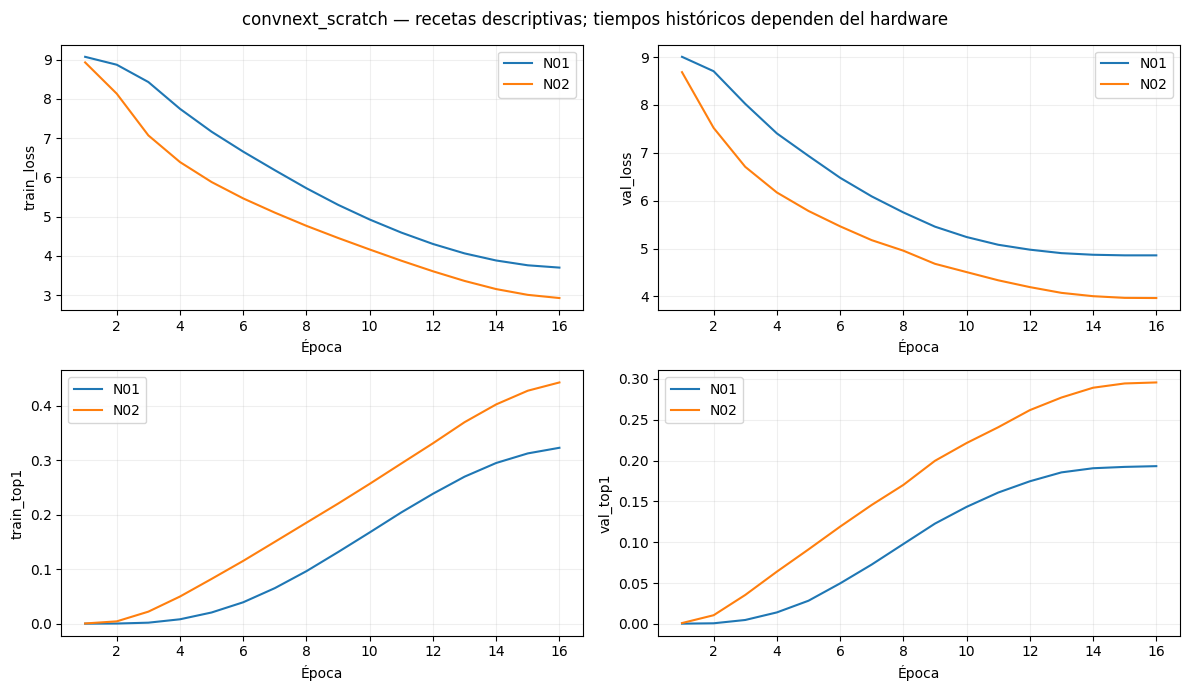

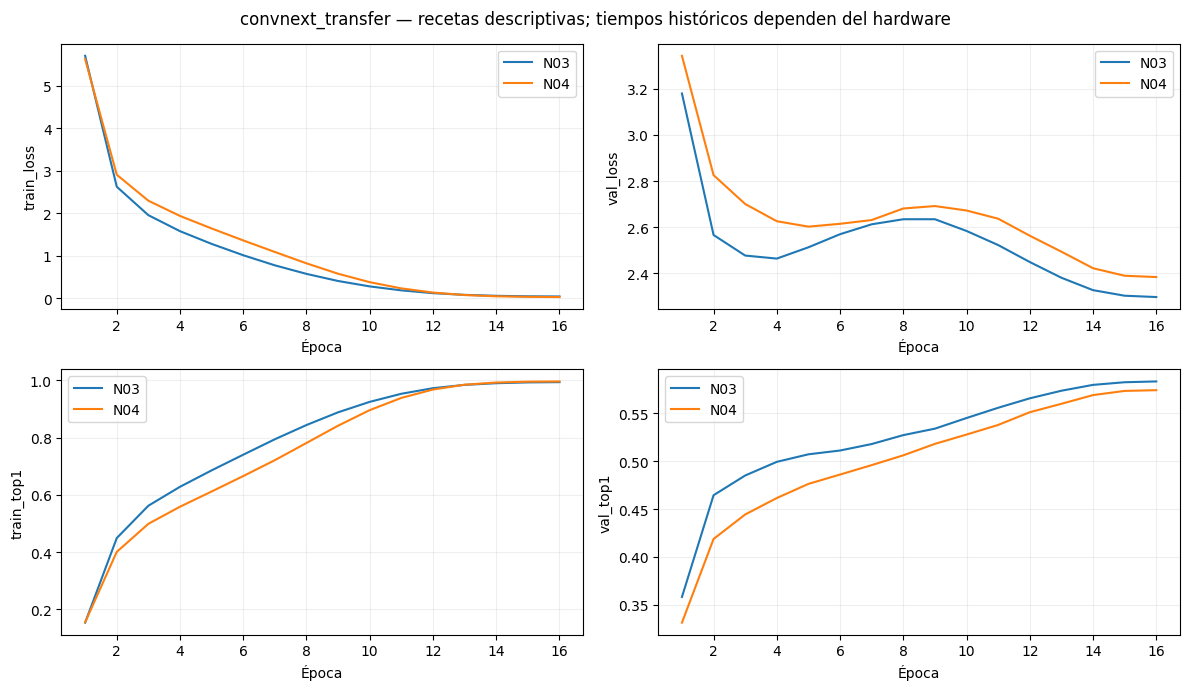

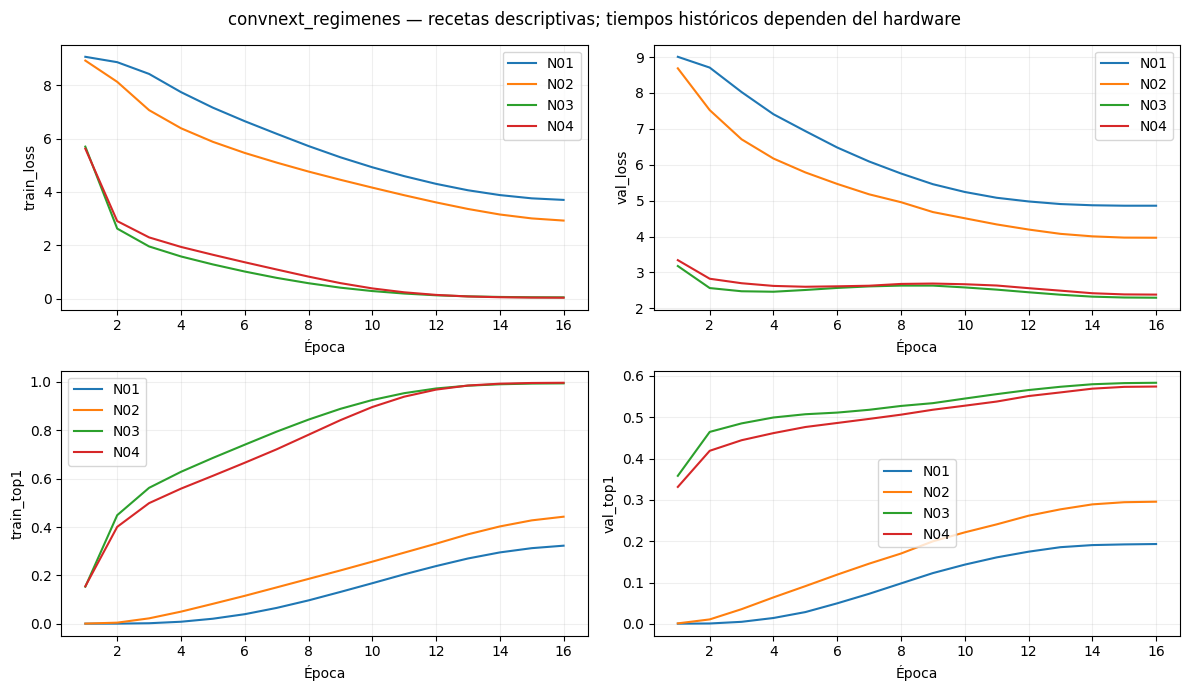

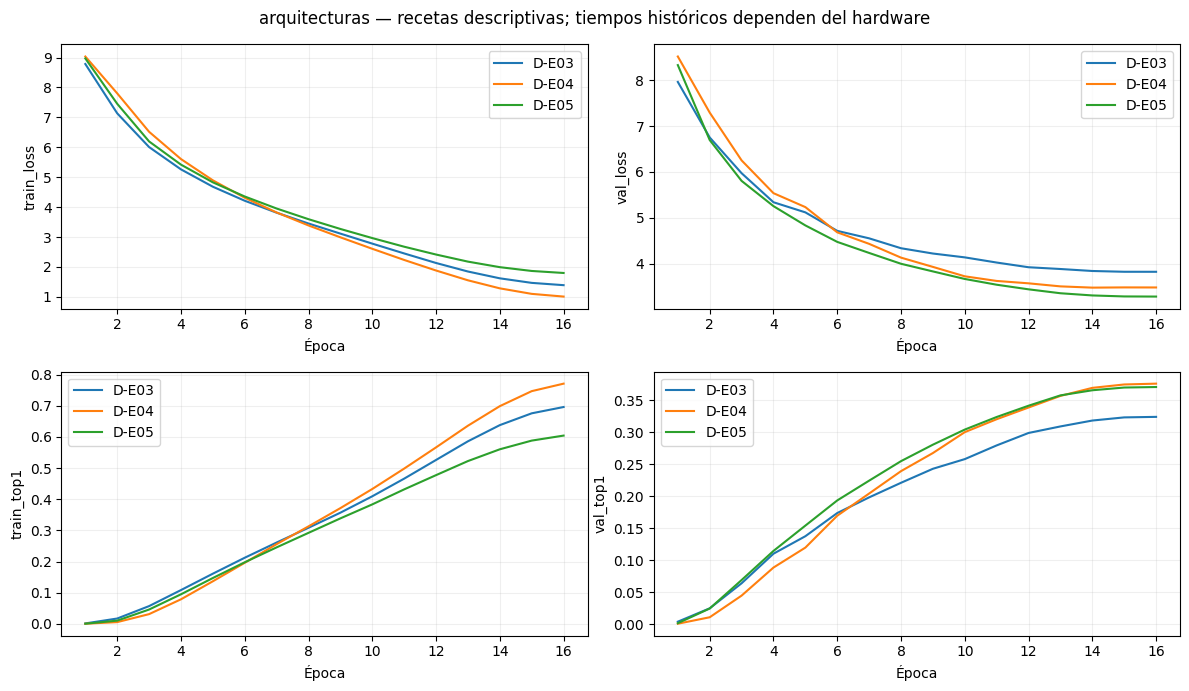

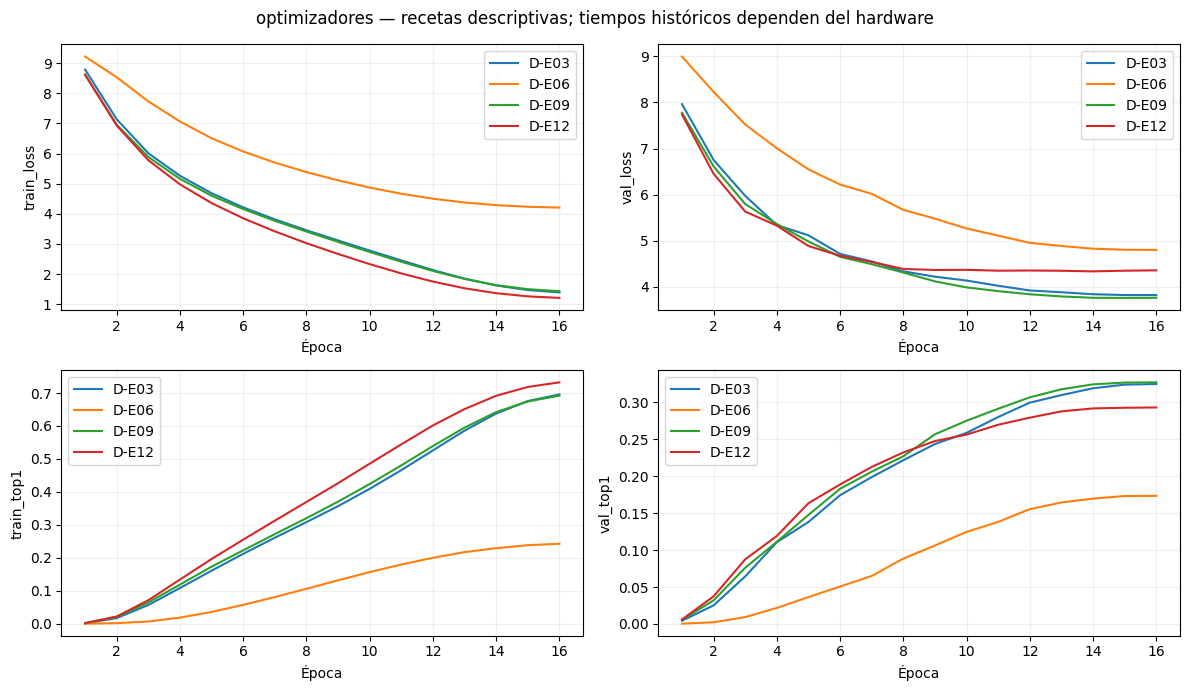

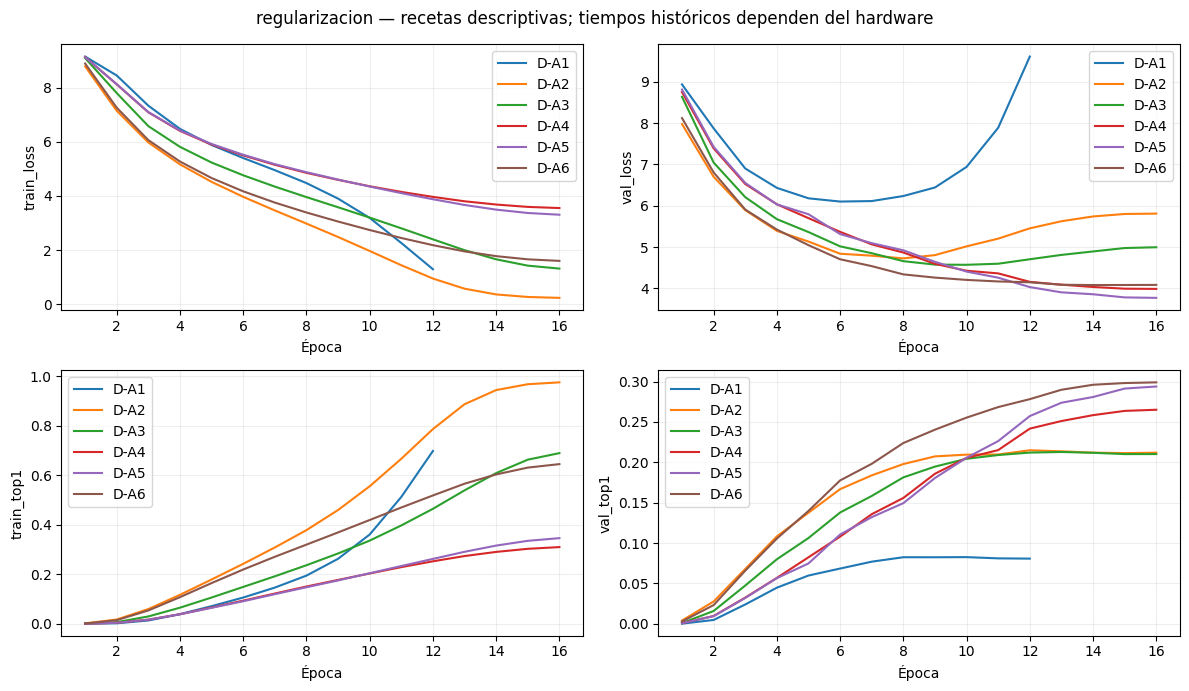

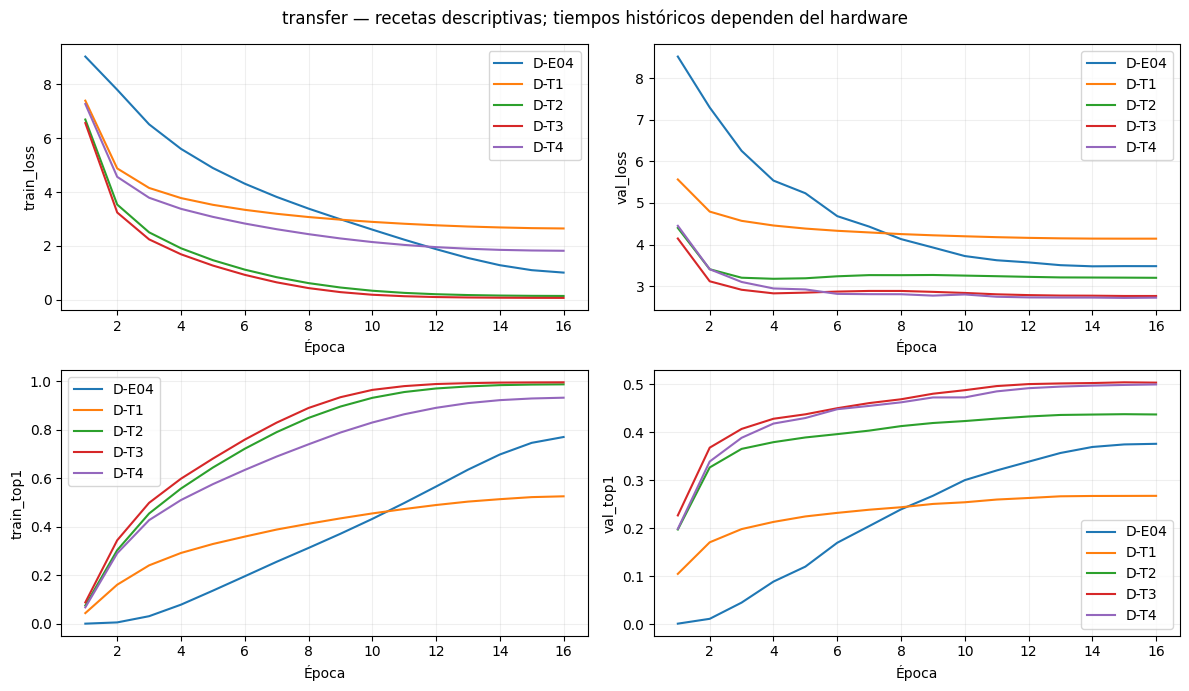

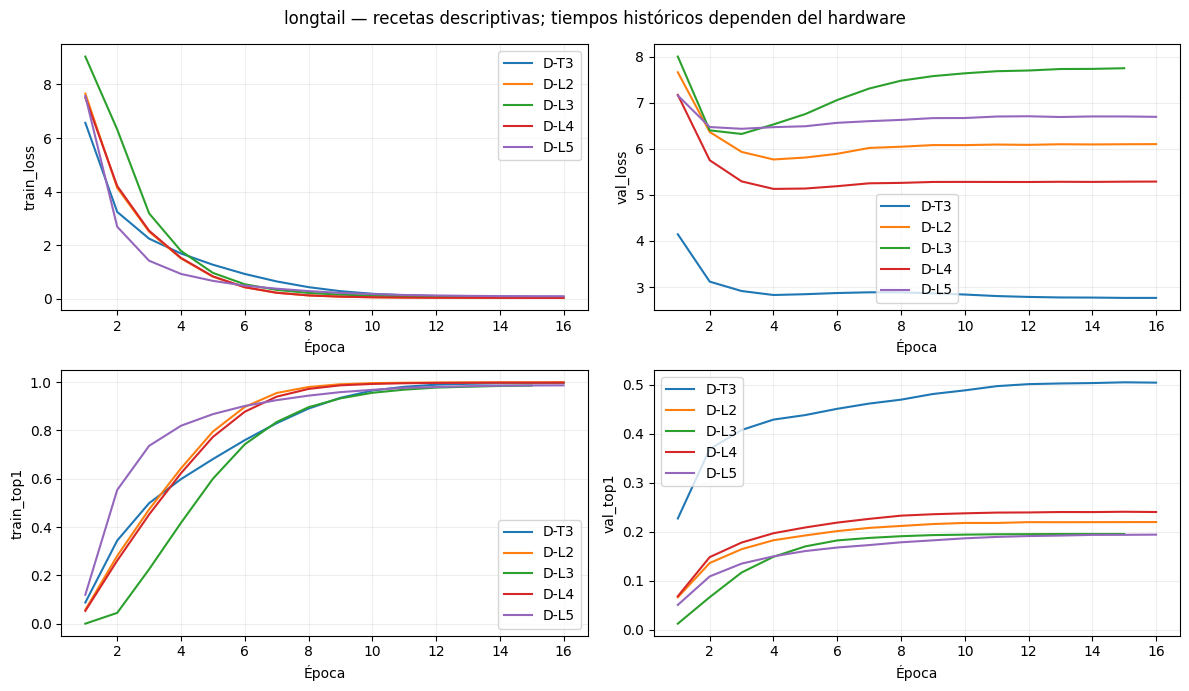

In [7]:
if MODE in ('review','report','collect'):
    from src.diego_workflow import report
    TABLE=report(ROOT,OUTPUT_ROOT,PLAN,with_images=(MODE=='report'))
elif MODE=='train' and RESULT.get('state')=='NEEDS_RESUME':
    print('Checkpoint completo; Slurm reencolará esta tarea.')


### Auditoría de entrega y ejemplos de N03

Se recalculan Top-1, Top-5, Macro-F1 y Weighted-F1 de los 30 NPZ publicados.
Cada ejecución evalúa 100000 imágenes, diez por especie, con el mismo orden de
etiquetas. Se comprueban fuentes, archivos y los pesos iniciales de cada pareja.
La auditoría usa los resultados archivados del protocolo original, separados
de cualquier repetición posterior con otro RUN_ID. No carga modelos ni infiere.

N03 es el mejor resultado observado. Sus 24 ejemplos se eligieron con semilla
0, seis por criterio; se muestran los primeros tres de cada uno con el recorte
central de 128 px utilizado para evaluar. La selección y hashes se verifican.
Los patrones visuales son descriptivos: no diagnostican etiquetas incorrectas
ni demuestran que el fondo cause errores.


30 ejecuciones verificadas sobre las mismas 100000 imágenes; fuentes e inicializaciones emparejadas verificadas.


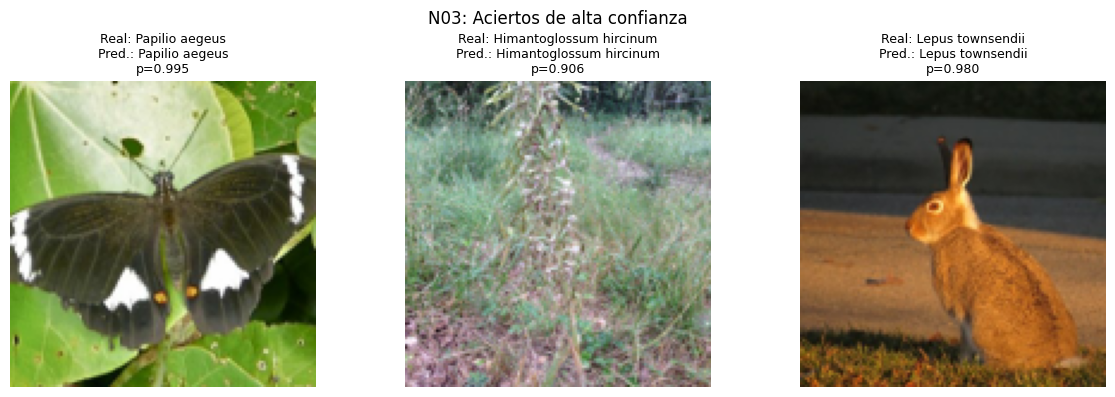

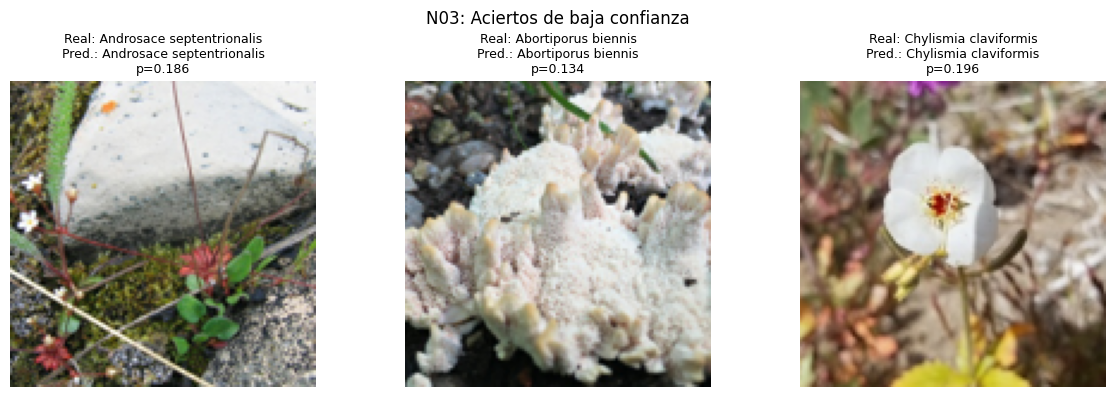

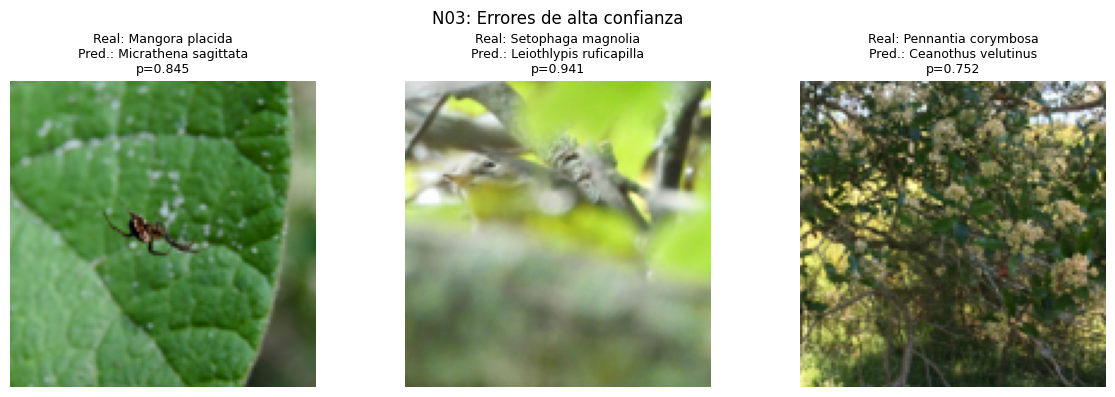

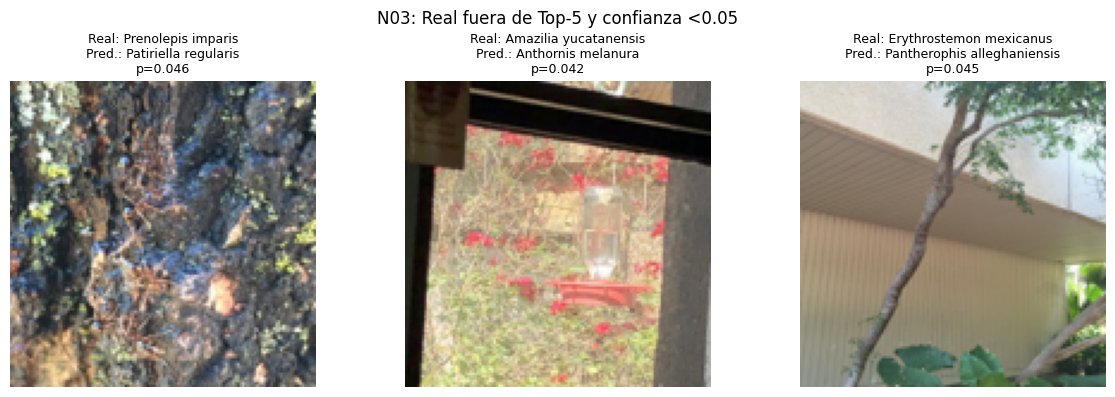

24 ejemplos auditados; 12 ilustrados. Semilla 0, recorte real de 128 px; observaciones visuales sin inferencia causal.


In [8]:
if MODE in ('review','report','collect'):
    from src.delivery_evidence import audit_delivery, show_n03_examples
    DELIVERY_AUDIT=audit_delivery(ROOT)
    show_n03_examples(ROOT)


## 6. Reflexión y límites de las conclusiones

Se complementa la evidencia de Diego con cuatro recetas ConvNeXt no publicadas
en su suite. No se repiten MLP, ResNet, EfficientNet ni sus ablaciones. Las dos
comparaciones principales cambian optimización bajo controles pareados. La
comparación histórica es contextual: arquitectura, preentrenamiento y recetas
pueden diferir, aunque el corpus, preprocesamiento, métricas y presupuesto sean
comparables. El entorno exacto original de Diego no está publicado.

ConvNeXt usa convoluciones depthwise 7×7, expansión/proyección, LayerNorm,
layer_scale y stochastic depth. Se ajustan todas las capas en ambos regímenes.
128 px favorece velocidad y compatibilidad con Diego, pero puede limitar el
detalle fino y la transferencia de pesos preentrenados a resolución mayor.

En 13 resúmenes, mejor época (argmax) difiere de la selección con min_delta.
El reporte reconstruye la época seleccionada y conserva métricas verificadas
del NPZ. No cambia los resultados de Diego. Reanudar tras early stopping no
añade otra época; los checkpoints se escriben atómicamente.

Una semilla no demuestra significancia. La validación selecciona pesos y no
equivale a test independiente. BF16, versiones, hardware y cudnn.benchmark
pueden cambiar resultados numéricos. Se conserva la política benchmark de Diego
por velocidad; `TORCH_DETERMINISTA=1` solicita algoritmos deterministas y debe
quedar constante en el par. Operadores incompatibles pueden emitir advertencias.
Reproducción bit a bit exige mismo entorno, GPU y operadores deterministas.

Los cuatro ejecutaron 16 épocas; early stopping estuvo habilitado pero no
detuvo antes del presupuesto. Se seleccionaron las épocas 15, 16, 15 y 15.
Top-1 de los checkpoints: N01 19.222%, N02 29.558%, N03 58.263%, N04 57.356%.
Desde cero, la receta Muon + Adam supera a Adam en 10.336 puntos; con ImageNet,
Adam supera a Muon + Adam en 0.907 puntos. Son resultados de estas recetas y
una semilla, sin prueba de superioridad general ni de máximo potencial.
Las métricas proceden de la validación completa; no se trasladan resultados
de subconjuntos ni se confunde el último punto de la curva con el checkpoint.
